# 🎬 Recommendation Systems for Personalized Content Discovery
### *Recreating the Magic of the Netflix Prize with Matrix Factorization & Ranking Models*

---

This notebook is a comprehensive, ground-up implementation of state-of-the-art recommendation algorithms, benchmarked against the legendary **Netflix Prize Dataset** (~100 Million ratings). 

### 🎯 Project Objectives
1. **Data Ingestion & EDA**: Handle massive sparse matrices and uncover temporal/user behavior patterns.
2. **Rating Prediction (RMSE)**: Implement **Bias Baseline**, **Funk SVD**, and **SVD++** using Numba JIT-compiled SGD.
3. **Top-K Ranking (MAP@10)**: Implement **BPR (Bayesian Personalized Ranking)** to directly optimize recommendation lists.
4. **Ensembling**: Learn optimal blending weights via **Linear Stacking** on a leakage-free validation slice.
5. **Explainability & Cold-Start**: Provide "Because you liked..." rationales and handle new users gracefully.


## Stage 0 — Setup, Kaggle paths & configuration

In [ ]:
# numba is preinstalled on Kaggle. This guard installs it only if missing.
try:
    import numba  # noqa
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "numba"])
    import numba
print("numba", numba.__version__)

In [3]:
import os, gc, time, math, pickle
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
from numba import njit, prange
import warnings; warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.style.use('dark_background')
sns.set_theme(style="dark", palette="Spectral") 

plt.rcParams['figure.facecolor'] = '#0d1117'
plt.rcParams['axes.facecolor'] = '#161b22'
plt.rcParams['grid.color'] = '#30363d'
plt.rcParams['text.color'] = '#c9d1d9'
plt.rcParams['axes.labelcolor'] = '#c9d1d9'
plt.rcParams['xtick.color'] = '#8b949e'
plt.rcParams['ytick.color'] = '#8b949e'
plt.rcParams['axes.edgecolor'] = '#30363d'
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
print("Ready · numpy", np.__version__, "· pandas", pd.__version__)

Ready · numpy 2.4.6 · pandas 2.3.3


In [4]:
# ----------------------------------------------------------------------------
# CONFIGURATION  (auto-detects Kaggle vs local)
# ----------------------------------------------------------------------------
# Kaggle mounts the dataset read-only here:
KAGGLE_DIR = "/kaggle/input/datasets/organizations/netflix-inc/netflix-prize-data"
LOCAL_DIR  = "archive"
DATA_DIR   = KAGGLE_DIR if os.path.isdir(KAGGLE_DIR) else LOCAL_DIR

# Writable output dir: /kaggle/working on Kaggle, else local ./artifacts
ARTIFACTS  = "/kaggle/working" if os.path.isdir("/kaggle/working") else "artifacts"
os.makedirs(ARTIFACTS, exist_ok=True)
print(f"DATA_DIR  = {DATA_DIR}")
print(f"ARTIFACTS = {ARTIFACTS}")

# ---- SCALE SWITCH ----------------------------------------------------------
FULL_RUN = True     # False = combined_data_1.txt (~24M). True = all 4 files (~100M).

ALL_RAW_FILES = ["combined_data_1.txt", "combined_data_2.txt",
                 "combined_data_3.txt", "combined_data_4.txt"]
RAW_FILES = ALL_RAW_FILES if FULL_RUN else ALL_RAW_FILES[:1]

# ---- shared ----------------------------------------------------------------
MIN_USER_RATINGS    = 5 if FULL_RUN else 20   # SGD trains on observed entries -> we can keep more users
MIN_MOVIE_RATINGS   = 20
TOP_K               = 10
RELEVANCE_THRESHOLD = 3.5
N_EVAL_USERS        = 3000
RANK_SAMPLE_SEED    = 7

# ---- Funk SVD / SVD++ ------------------------------------------------------
MF_FACTORS   = 100 if FULL_RUN else 60
MF_EPOCHS    = 25
MF_LR        = 0.005
MF_REG       = 0.02
MF_LR_DECAY  = 0.95          # multiply LR each epoch
USE_SVDPP    = True          # set False to skip SVD++ (it is slower)
SVDPP_EPOCHS = 15

# ---- BPR (ranking) ---------------------------------------------------------
BPR_FACTORS  = 64
BPR_EPOCHS   = 20
BPR_LR       = 0.02
BPR_REG      = 0.01
BPR_POS_THRESHOLD = 4.0      # treat rating >= 4 as a positive interaction for ranking

# ---- Ensemble --------------------------------------------------------------
# weights for [baseline, funk_svd, svdpp]; normalized automatically
ENSEMBLE_WEIGHTS = {"Baseline": 0.15, "FunkSVD": 0.55, "SVD++": 0.30}

LAMBDA_BIAS = 10.0
CACHE_TAG   = "full" if FULL_RUN else "sub"
RATINGS_CACHE = os.path.join(ARTIFACTS, f"ratings_{CACHE_TAG}.pkl")

print(f"\nFULL_RUN={FULL_RUN} | files={RAW_FILES}")
print(f"MF: factors={MF_FACTORS}, epochs={MF_EPOCHS}, lr={MF_LR}, reg={MF_REG} | SVD++={USE_SVDPP}")
print(f"BPR: factors={BPR_FACTORS}, epochs={BPR_EPOCHS}")

DATA_DIR  = /kaggle/input/datasets/organizations/netflix-inc/netflix-prize-data
ARTIFACTS = /kaggle/working

FULL_RUN=True | files=['combined_data_1.txt', 'combined_data_2.txt', 'combined_data_3.txt', 'combined_data_4.txt']
MF: factors=100, epochs=25, lr=0.005, reg=0.02 | SVD++=True
BPR: factors=64, epochs=20


## Stage 1 — Data Ingestion (Kaggle-aware)

This stage handles **data ingestion and preprocessing** for the Netflix ratings dataset in a Kaggle-compatible way. The code reads each raw ratings file, identifies the movie ID rows, propagates those IDs to the corresponding user-rating records, removes unnecessary header rows, converts columns to memory-efficient data types, and parses dates into a proper datetime format. The processed data from all files is then combined into a single DataFrame. To avoid repeating this expensive parsing step on every run, the cleaned dataset is cached as a pickle file and loaded directly if it already exists. Finally, the code displays basic dataset statistics such as the total number of ratings, unique users, unique movies, and memory usage.


In [5]:
def load_ratings(files):
    parts = []
    for fn in files:
        path = os.path.join(DATA_DIR, fn)
        t0 = time.time()
        df = pd.read_csv(path, header=None, names=["userId", "rating", "date"])
        is_header = df["rating"].isna()
        df["movieId"] = df["userId"].where(is_header).str.rstrip(":")
        df["movieId"] = df["movieId"].ffill()
        df = df[~is_header]
        df = df.astype({"userId": "int32", "rating": "int8"})
        df["movieId"] = df["movieId"].astype("int32").astype("int16")
        df["date"] = pd.to_datetime(df["date"])
        parts.append(df[["userId", "movieId", "rating", "date"]])
        print(f"  parsed {fn}: {len(df):,} ratings  ({time.time()-t0:.1f}s)")
        del df; gc.collect()
    return pd.concat(parts, ignore_index=True)

if os.path.exists(RATINGS_CACHE):
    print("Loading cached ratings ->", RATINGS_CACHE)
    ratings = pd.read_pickle(RATINGS_CACHE)
else:
    print("Parsing raw files (first run only)...")
    ratings = load_ratings(RAW_FILES)
    try:
        ratings.to_pickle(RATINGS_CACHE); print("Cached ->", RATINGS_CACHE)
    except Exception as e:
        print("(cache skipped:", e, ")")

print(f"\nTotal ratings: {len(ratings):,} | users {ratings['userId'].nunique():,} | "
      f"movies {ratings['movieId'].nunique():,} | mem {ratings.memory_usage(deep=True).sum()/1e6:,.0f} MB")
ratings.head()

Parsing raw files (first run only)...
  parsed combined_data_1.txt: 24,053,764 ratings  (38.0s)
  parsed combined_data_2.txt: 26,977,591 ratings  (41.4s)
  parsed combined_data_3.txt: 22,601,629 ratings  (34.8s)
  parsed combined_data_4.txt: 26,847,523 ratings  (42.7s)
Cached -> /kaggle/working/ratings_full.pkl

Total ratings: 100,480,507 | users 480,189 | movies 17,770 | mem 1,507 MB


,userId,movieId,rating,date
0,1488844,1,3,2005-09-06
1,822109,1,5,2005-05-13
2,885013,1,4,2005-10-19
3,30878,1,4,2005-12-26
4,823519,1,3,2004-05-03


### Movie titles — handles both `movie_titles.csv` and `.txt` 

In [5]:
def load_movie_titles(data_dir):
    for name in ["movie_titles.csv", "movie_titles.txt"]:
        p = os.path.join(data_dir, name)
        if os.path.exists(p):
            rows = []
            with open(p, encoding="latin-1") as f:
                for line in f:
                    parts = line.rstrip("\n").split(",", 2)
                    if len(parts) == 3:
                        rows.append(parts)
            m = pd.DataFrame(rows, columns=["movieId", "year", "title"])
            m["movieId"] = m["movieId"].astype("int32")
            m["year"] = pd.to_numeric(m["year"], errors="coerce")
            return m
    raise FileNotFoundError("movie_titles file not found in " + data_dir)

movies = load_movie_titles(DATA_DIR)
title_of = dict(zip(movies["movieId"], movies["title"]))
print(f"Loaded {len(movies):,} movie titles")
movies.head()

Loaded 17,770 movie titles


,movieId,year,title
0,1,"2,003.0000",Dinosaur Planet
1,2,"2,004.0000",Isle of Man TT 2004 Review
2,3,"1,997.0000",Character
3,4,"1,994.0000",Paula Abdul's Get Up & Dance
4,5,"2,004.0000",The Rise and Fall of ECW


## Stage 2 — Train/Test split via `probe.txt` 

This stage creates a **leakage-free train/test split** using Netflix’s official `probe.txt` file. The probe set identifies specific user–movie rating pairs that are reserved for testing, while all remaining ratings are used for training. This ensures the model is evaluated on unseen interactions and prevents information from the test set from leaking into the training process.



In [6]:
def parse_probe(path):
    movie_ids, user_ids, cur = [], [], -1
    with open(path) as f:
        for line in f:
            line = line.rstrip()
            if line.endswith(":"):
                cur = int(line[:-1])
            else:
                movie_ids.append(cur); user_ids.append(int(line))
    return pd.DataFrame({"movieId": np.array(movie_ids, "int16"),
                         "userId":  np.array(user_ids, "int32")})

probe = parse_probe(os.path.join(DATA_DIR, "probe.txt"))
probe = probe[probe["movieId"].isin(set(ratings["movieId"].unique()))].reset_index(drop=True)
print(f"probe pairs usable in current data: {len(probe):,}")

merged = ratings.merge(probe[["userId", "movieId"]], on=["userId", "movieId"],
                       how="left", indicator=True)
train = merged[merged["_merge"] == "left_only"].drop(columns="_merge").reset_index(drop=True)
test  = merged[merged["_merge"] == "both"].drop(columns="_merge").reset_index(drop=True)
del merged; gc.collect()
print(f"Train: {len(train):,} | Test: {len(test):,}")

probe pairs usable in current data: 1,408,395
Train: 99,072,112 | Test: 1,408,395


## Stage 3 — EDA (essentials) + Preprocessing



This stage focuses on understanding the structure and characteristics of the Netflix dataset before model development. Key statistics such as the total number of ratings, unique users, unique movies, dataset sparsity, and average rating are computed to provide an overview of the data. Several visualizations are generated, including the rating distribution and the distributions of ratings per user and ratings per movie, which help reveal user activity patterns, movie popularity trends, and potential data imbalances. Analyzing these characteristics is important because recommendation datasets are typically highly sparse, with most users rating only a small fraction of available movies. The insights gained from this analysis guide subsequent preprocessing and model selection decisions, ensuring that the recommendation algorithms are trained on well-understood data.




Ratings 100,480,507 | Users 480,189 | Movies 17,770 | Density 1.178% | Global Mean Rating 3.6043


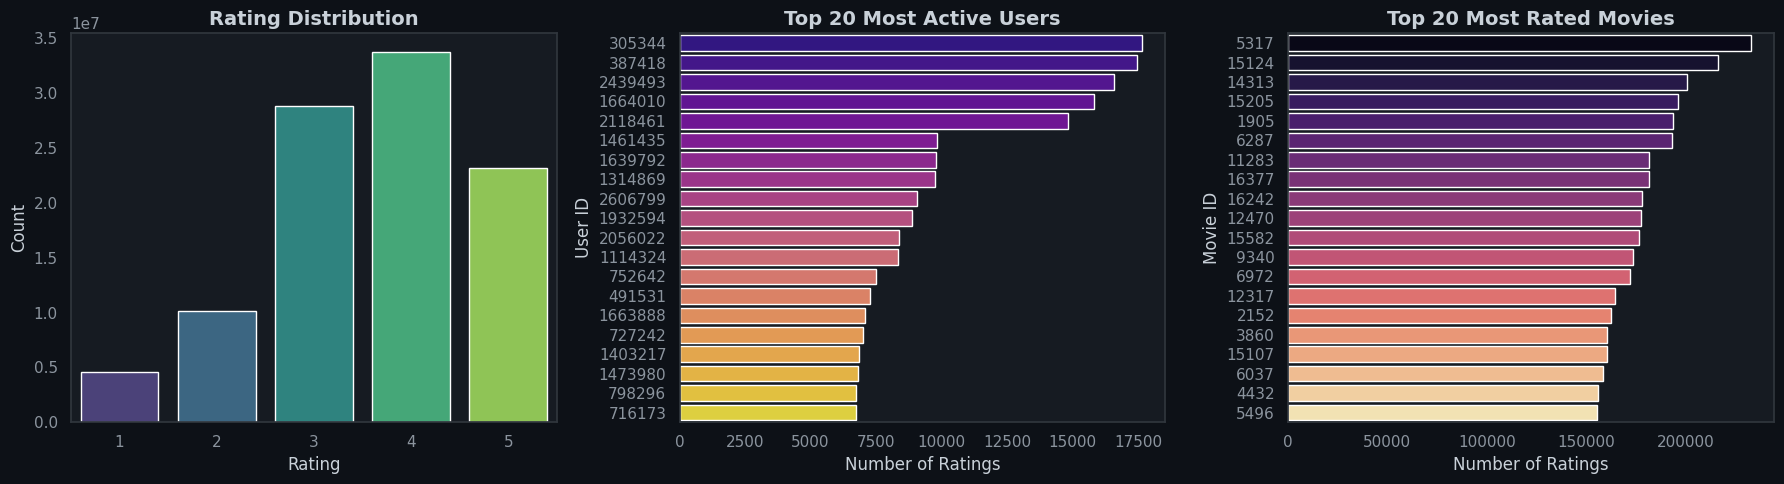

In [7]:
# ===========================
# Basic Dataset Statistics
# ===========================

n_users = ratings["userId"].nunique()
n_movies = ratings["movieId"].nunique()
sparsity = 1 - len(ratings) / (n_users * n_movies)

print(
    f"Ratings {len(ratings):,} | "
    f"Users {n_users:,} | "
    f"Movies {n_movies:,} | "
    f"Density {100*(1-sparsity):.3f}% | "
    f"Global Mean Rating {ratings['rating'].mean():.4f}"
)

# ===========================
# Exploratory Data Analysis
# ===========================

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Rating distribution
vc = ratings["rating"].value_counts().sort_index()
sns.barplot(x=vc.index, y=vc.values, palette="viridis", ax=ax[0])

ax[0].set_title("Rating Distribution", fontsize=14, weight="bold")
ax[0].set_xlabel("Rating")
ax[0].set_ylabel("Count")

# Top users by number of ratings
user_counts = ratings.groupby("userId").size().sort_values(ascending=False).head(20)

sns.barplot(
    x=user_counts.values,
    y=[str(i) for i in user_counts.index],
    palette="plasma",
    ax=ax[1]
)

ax[1].set_title("Top 20 Most Active Users", fontsize=14, weight="bold")
ax[1].set_xlabel("Number of Ratings")
ax[1].set_ylabel("User ID")

# Top movies by number of ratings
movie_counts = ratings.groupby("movieId").size().sort_values(ascending=False).head(20)

sns.barplot(
    x=movie_counts.values,
    y=[str(i) for i in movie_counts.index],
    palette="magma",
    ax=ax[2]
)

ax[2].set_title("Top 20 Most Rated Movies", fontsize=14, weight="bold")
ax[2].set_xlabel("Number of Ratings")
ax[2].set_ylabel("Movie ID")

plt.tight_layout()
plt.show()

### ⏳ Temporal Analysis: How did rating behavior evolve?
Beyond basic distributions, let's explore **how user activity exploded over time** and whether users became more generous (or critical) in their ratings as the platform grew.


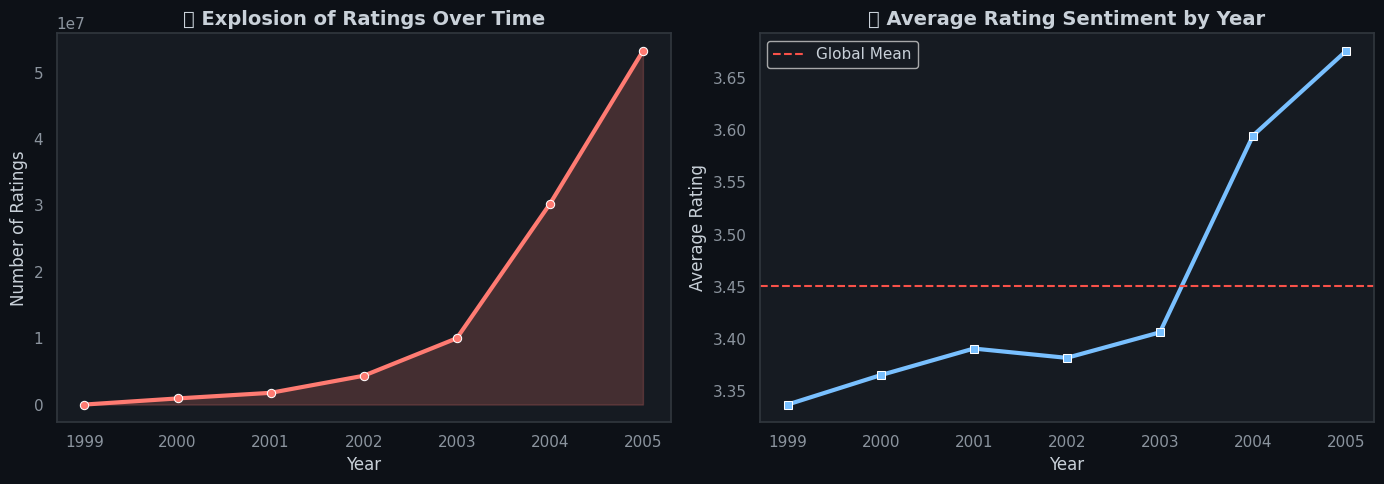

In [9]:
# Extract Year from Date for temporal analysis
ratings['rating_year'] = ratings['date'].dt.year

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Volume of Ratings Over Time
yearly_counts = ratings.groupby('rating_year').size()
sns.lineplot(x=yearly_counts.index, y=yearly_counts.values, ax=axes[0], linewidth=3, marker='o', color='#ff7b72')
axes[0].set_title('📈 Explosion of Ratings Over Time', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Ratings')
axes[0].fill_between(yearly_counts.index, yearly_counts.values, color='#ff7b72', alpha=0.2)

# 2. Average Rating Sentiment Over Time
yearly_mean = ratings.groupby('rating_year')['rating'].mean()
sns.lineplot(x=yearly_mean.index, y=yearly_mean.values, ax=axes[1], linewidth=3, color='#79c0ff', marker='s')
axes[1].set_title('⭐ Average Rating Sentiment by Year', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Average Rating')
axes[1].axhline(yearly_mean.mean(), color='#f85149', linestyle='--', label='Global Mean')
axes[1].legend()

plt.tight_layout()
plt.show()

### Preprocessing → index maps + CSR arrays

We filter cold users/movies, build contiguous id maps, and produce **flat int32/float32 arrays**
(`u_arr, i_arr, r_arr`) plus a CSR layout — the exact format the numba SGD kernels iterate over.


### 🧠 The Model Lineup

| Model Type | Algorithm | Objective | Best For |
| :--- | :--- | :--- | :--- |
| **Baseline** | Regularized Bias | RMSE | Cold-start fallback, Ensemble base |
| **Latent Factor** | Funk SVD | RMSE | Capturing explicit user-item interactions |
| **Implicit** | SVD++ | RMSE | Leveraging *which* movies users rate (not just the score) |
| **Ranking** | BPR | MAP@10 | Generating the actual Top-10 recommendation lists |
| **Meta-Model** | Linear Stacking | RMSE | Combining predictions to minimize squared error |


In [44]:
uc = train["userId"].value_counts(); mc = train["movieId"].value_counts()
keep_u = uc[uc >= MIN_USER_RATINGS].index
keep_m = mc[mc >= MIN_MOVIE_RATINGS].index
tr = train[train["userId"].isin(keep_u) & train["movieId"].isin(keep_m)].copy()

u_cat = tr["userId"].astype("category"); m_cat = tr["movieId"].astype("category")
user_ids  = u_cat.cat.categories.to_numpy()
movie_ids = m_cat.cat.categories.to_numpy()
user_to_row  = {int(u): i for i, u in enumerate(user_ids)}
movie_to_col = {int(m): j for j, m in enumerate(movie_ids)}
n_u, n_m = len(user_ids), len(movie_ids)

u_arr = u_cat.cat.codes.to_numpy().astype(np.int32)
i_arr = m_cat.cat.codes.to_numpy().astype(np.int32)
r_arr = tr["rating"].to_numpy().astype(np.float32)
global_mean = float(r_arr.mean())
print(f"Train(filtered): {len(r_arr):,} ratings | users {n_u:,} | movies {n_m:,} | mean {global_mean:.4f}")

# CSR (by user) for SVD++ implicit sets and fast per-user item lookups
R = sp.csr_matrix((r_arr, (u_arr, i_arr)), shape=(n_u, n_m), dtype=np.float32)
csr_indptr  = R.indptr.astype(np.int32)
csr_indices = R.indices.astype(np.int32)
csr_data    = R.data.astype(np.float32)
print(f"CSR ready: nnz={R.nnz:,}")

Train(filtered): 99,048,358 ratings | users 470,858 | movies 17,758 | mean 3.6033
CSR ready: nnz=99,048,358


In [ ]:

_te = test.copy()
_te["row"] = _te["userId"].map(user_to_row)
_te["col"] = _te["movieId"].map(movie_to_col)
_before = len(_te)
_te = _te.dropna(subset=["row", "col"]).copy()
_te["row"] = _te["row"].astype(np.int32); _te["col"] = _te["col"].astype(np.int32)

_rng = np.random.RandomState(RANDOM_STATE)
_blend_mask = _rng.rand(len(_te)) < 0.25
blend_eval = _te[_blend_mask].copy()      # used ONLY to learn ensemble weights
test_eval  = _te[~_blend_mask].copy()     # used for ALL reported metrics (leakage-free)

te_rows = test_eval["row"].to_numpy(); te_cols = test_eval["col"].to_numpy()
te_true = test_eval["rating"].to_numpy().astype(np.float32)
bl_rows = blend_eval["row"].to_numpy(); bl_cols = blend_eval["col"].to_numpy()
bl_true = blend_eval["rating"].to_numpy().astype(np.float32)
print(f"Test usable: {len(_te):,} (dropped {_before-len(_te):,} cold-start pairs)")
print(f"  -> blend-fit slice : {len(blend_eval):,}  (learn ensemble weights)")
print(f"  -> final-eval slice: {len(test_eval):,}  (all reported metrics)")

Test usable: 1,401,715 (dropped 6,680 cold-start pairs)
  -> blend-fit slice : 350,072  (learn ensemble weights)
  -> final-eval slice: 1,051,643  (all reported metrics)


## Stage 4 — Model 1: Regularised Bias Baseline (reference)

$\hat r_{ui} = \mu + b_u + b_i$ — cheap, robust, and the reference every later model must beat. Also
serves as the **cold-start fallback** and a component of the ensemble.


In [46]:
mu = global_mean
user_cnt = np.bincount(u_arr, minlength=n_u).astype(np.float32)
item_cnt = np.bincount(i_arr, minlength=n_m).astype(np.float32)
user_sum = np.bincount(u_arr, weights=r_arr, minlength=n_u)
item_sum = np.bincount(i_arr, weights=r_arr, minlength=n_m)

b_i = ((item_sum - mu * item_cnt) / (LAMBDA_BIAS + item_cnt)).astype(np.float32)
b_i_user_sum = np.bincount(u_arr, weights=b_i[i_arr], minlength=n_u)
b_u = ((user_sum - mu * user_cnt - b_i_user_sum) / (LAMBDA_BIAS + user_cnt)).astype(np.float32)

def predict_baseline(rows, cols):
    return np.clip(mu + b_u[rows] + b_i[cols], 1.0, 5.0)
def baseline_user_scores(row):
    return np.clip(mu + b_u[row] + b_i, 1.0, 5.0).astype(np.float32)
print(f"Baseline ready | b_u[{b_u.min():.2f},{b_u.max():.2f}] b_i[{b_i.min():.2f},{b_i.max():.2f}]")

Baseline ready | b_u[-2.47,1.81] b_i[-2.18,1.12]


## Stage 5 — Model 2: Funk SVD (SGD Matrix Factorization)

The model that put matrix factorization on the map during the Prize (Simon Funk, 2006).

$$\hat r_{ui} = \mu + b_u + b_i + \mathbf{p}_u^\top \mathbf{q}_i$$

Crucially, it is trained by **stochastic gradient descent over only the observed ratings** — unlike v1's
`svds`, which implicitly treated missing entries as 0. For each known rating we take the error
$e_{ui} = r_{ui} - \hat r_{ui}$ and update:

$$b_u \mathrel{+}= \gamma(e_{ui} - \lambda b_u),\quad b_i \mathrel{+}= \gamma(e_{ui} - \lambda b_i)$$
$$\mathbf{p}_u \mathrel{+}= \gamma(e_{ui}\mathbf{q}_i - \lambda \mathbf{p}_u),\quad
  \mathbf{q}_i \mathrel{+}= \gamma(e_{ui}\mathbf{p}_u - \lambda \mathbf{q}_i)$$

The training loop is **JIT-compiled with numba** so 24M–100M updates/epoch run in seconds. We hold out a
small slice for **early-stopping / LR decay**.


In [47]:
@njit(cache=True, fastmath=True)
def funk_svd_epoch(u_arr, i_arr, r_arr, bu, bi, P, Q, mu, lr, reg, order):
    n = order.shape[0]
    f = P.shape[1]
    se = 0.0
    for idx in range(n):
        t = order[idx]
        u = u_arr[t]; i = i_arr[t]
        pred = mu + bu[u] + bi[i]
        for k in range(f):
            pred += P[u, k] * Q[i, k]
        if pred > 5.0: pred = 5.0
        elif pred < 1.0: pred = 1.0
        e = r_arr[t] - pred
        se += e * e
        bu[u] += lr * (e - reg * bu[u])
        bi[i] += lr * (e - reg * bi[i])
        for k in range(f):
            puk = P[u, k]; qik = Q[i, k]
            P[u, k] += lr * (e * qik - reg * puk)
            Q[i, k] += lr * (e * puk - reg * qik)
    return se

In [48]:
def train_funk_svd(u_arr, i_arr, r_arr, n_u, n_m, f, epochs, lr, reg, decay, seed=RANDOM_STATE):
    rng = np.random.RandomState(seed)
    P = (rng.normal(0, 0.1, (n_u, f))).astype(np.float32)
    Q = (rng.normal(0, 0.1, (n_m, f))).astype(np.float32)
    bu = np.zeros(n_u, np.float32); bi = np.zeros(n_m, np.float32)

    # small internal validation slice for monitoring
    n = len(r_arr)
    val_mask = rng.rand(n) < 0.02
    tr_idx = np.where(~val_mask)[0].astype(np.int64)
    va_u, va_i, va_r = u_arr[val_mask], i_arr[val_mask], r_arr[val_mask]

    cur_lr = lr; best = 1e9; best_state = None
    for ep in range(epochs):
        order = tr_idx.copy(); rng.shuffle(order)
        se = funk_svd_epoch(u_arr, i_arr, r_arr, bu, bi, P, Q, mu, cur_lr, reg, order)
        # validation RMSE
        vp = mu + bu[va_u] + bi[va_i] + np.einsum("ij,ij->i", P[va_u], Q[va_i])
        vp = np.clip(vp, 1, 5)
        vr = np.sqrt(np.mean((va_r - vp) ** 2))
        if vr < best - 1e-4:
            best = vr; best_state = (P.copy(), Q.copy(), bu.copy(), bi.copy())
        print(f"  epoch {ep+1:2d}/{epochs} | train RMSE {np.sqrt(se/len(order)):.4f} | "
              f"val RMSE {vr:.4f} | lr {cur_lr:.4f}")
        cur_lr *= decay
    P, Q, bu, bi = best_state
    print(f"Funk SVD best val RMSE = {best:.4f}")
    return P, Q, bu, bi

print("Training Funk SVD ...")
t0 = time.time()
P_f, Q_f, bu_f, bi_f = train_funk_svd(u_arr, i_arr, r_arr, n_u, n_m,
                                      MF_FACTORS, MF_EPOCHS, MF_LR, MF_REG, MF_LR_DECAY)
print(f"trained in {time.time()-t0:.1f}s")

Training Funk SVD ...
  epoch  1/25 | train RMSE 0.9509 | val RMSE 0.9310 | lr 0.0050
  epoch  2/25 | train RMSE 0.9135 | val RMSE 0.9035 | lr 0.0047
  epoch  3/25 | train RMSE 0.8903 | val RMSE 0.8893 | lr 0.0045
  epoch  4/25 | train RMSE 0.8755 | val RMSE 0.8777 | lr 0.0043
  epoch  5/25 | train RMSE 0.8625 | val RMSE 0.8679 | lr 0.0041
  epoch  6/25 | train RMSE 0.8512 | val RMSE 0.8600 | lr 0.0039
  epoch  7/25 | train RMSE 0.8417 | val RMSE 0.8536 | lr 0.0037
  epoch  8/25 | train RMSE 0.8337 | val RMSE 0.8486 | lr 0.0035
  epoch  9/25 | train RMSE 0.8269 | val RMSE 0.8444 | lr 0.0033
  epoch 10/25 | train RMSE 0.8208 | val RMSE 0.8409 | lr 0.0032
  epoch 11/25 | train RMSE 0.8153 | val RMSE 0.8379 | lr 0.0030
  epoch 12/25 | train RMSE 0.8104 | val RMSE 0.8352 | lr 0.0028
  epoch 13/25 | train RMSE 0.8058 | val RMSE 0.8330 | lr 0.0027
  epoch 14/25 | train RMSE 0.8016 | val RMSE 0.8310 | lr 0.0026
  epoch 15/25 | train RMSE 0.7977 | val RMSE 0.8292 | lr 0.0024
  epoch 16/25 | tr

  epoch  4/25 | train RMSE 0.9119 | val RMSE 0.9153 | lr 0.0043


  epoch  5/25 | train RMSE 0.8996 | val RMSE 0.9062 | lr 0.0041


  epoch  6/25 | train RMSE 0.8897 | val RMSE 0.9001 | lr 0.0039


  epoch  7/25 | train RMSE 0.8824 | val RMSE 0.8958 | lr 0.0037


...

  epoch 21/25 | train RMSE 0.8186 | val RMSE 0.8665 | lr 0.0018


  epoch 22/25 | train RMSE 0.8153 | val RMSE 0.8655 | lr 0.0017


  epoch 23/25 | train RMSE 0.8122 | val RMSE 0.8645 | lr 0.0016


  epoch 24/25 | train RMSE 0.8092 | val RMSE 0.8637 | lr 0.0015


  epoch 25/25 | train RMSE 0.8063 | val RMSE 0.8631 | lr 0.0015
Funk SVD best val RMSE = 0.8631
trained in 475.3s


In [49]:
def predict_funk(rows, cols):
    base = mu + bu_f[rows] + bi_f[cols]
    inter = np.einsum("ij,ij->i", P_f[rows], Q_f[cols])
    return np.clip(base + inter, 1.0, 5.0)
def funk_user_scores(row):
    return np.clip(mu + bu_f[row] + bi_f + P_f[row] @ Q_f.T, 1.0, 5.0).astype(np.float32)
print("Funk SVD predictors ready.")

Funk SVD predictors ready.


## Stage 6 — Model 3: SVD++ (implicit feedback)

SVD++ extends Funk SVD with the insight that **the very act of rating a movie is information** —
*which* items a user engaged with reveals taste, regardless of the score. Each user's factor is augmented
by the items they rated:

$$\hat r_{ui} = \mu + b_u + b_i + \mathbf{q}_i^\top\!\Big(\mathbf{p}_u + |N(u)|^{-\frac12}\!\!\sum_{j\in N(u)}\mathbf{y}_j\Big)$$

where $N(u)$ is the set of items user $u$ rated and $\mathbf{y}_j$ are implicit-item factors. This was a
**core component of the winning BellKor solution**. We process **per user** (numba) so the shared
implicit sum is computed once per user per epoch.

> Set `USE_SVDPP = False` in config to skip — it is ~2–3× slower than Funk SVD.


In [50]:
@njit(cache=True, fastmath=True)
def svdpp_epoch(indptr, indices, data, bu, bi, P, Q, Y, mu, lr, reg, user_order):
    f = P.shape[1]
    se = 0.0; cnt = 0
    for uu in range(user_order.shape[0]):
        u = user_order[uu]
        s, e = indptr[u], indptr[u + 1]
        nu = e - s
        if nu == 0:
            continue
        sqrt_inv = 1.0 / math.sqrt(nu)
        # implicit sum over rated items: sum_j Y[j]
        impl = np.zeros(f, dtype=np.float32)
        for idx in range(s, e):
            j = indices[idx]
            for k in range(f):
                impl[k] += Y[j, k]
        # effective user vector p_u + sqrt_inv * impl
        puf = np.empty(f, dtype=np.float32)
        for k in range(f):
            puf[k] = P[u, k] + sqrt_inv * impl[k]
        # accumulate gradient to apply to Y after the user's items
        grad_y = np.zeros(f, dtype=np.float32)
        for idx in range(s, e):
            i = indices[idx]
            pred = mu + bu[u] + bi[i]
            for k in range(f):
                pred += Q[i, k] * puf[k]
            if pred > 5.0: pred = 5.0
            elif pred < 1.0: pred = 1.0
            err = data[idx] - pred
            se += err * err; cnt += 1
            bu[u] += lr * (err - reg * bu[u])
            bi[i] += lr * (err - reg * bi[i])
            for k in range(f):
                qik = Q[i, k]; puk = P[u, k]
                P[u, k] += lr * (err * qik - reg * puk)
                Q[i, k] += lr * (err * puf[k] - reg * qik)
                grad_y[k] += err * qik
        # update implicit factors for this user's items
        for idx in range(s, e):
            j = indices[idx]
            for k in range(f):
                Y[j, k] += lr * (sqrt_inv * grad_y[k] - reg * Y[j, k])
    return se, cnt

In [51]:
def train_svdpp(indptr, indices, data, n_u, n_m, f, epochs, lr, reg, decay,
                P_init=None, Q_init=None, bu_init=None, bi_init=None, seed=RANDOM_STATE):
    rng = np.random.RandomState(seed)
    # warm-start from Funk SVD if provided (faster convergence)
    P = P_init.copy() if P_init is not None else rng.normal(0, 0.1, (n_u, f)).astype(np.float32)
    Q = Q_init.copy() if Q_init is not None else rng.normal(0, 0.1, (n_m, f)).astype(np.float32)
    bu = bu_init.copy() if bu_init is not None else np.zeros(n_u, np.float32)
    bi = bi_init.copy() if bi_init is not None else np.zeros(n_m, np.float32)
    Y  = (rng.normal(0, 0.01, (n_m, f))).astype(np.float32)
    cur_lr = lr
    for ep in range(epochs):
        order = np.arange(n_u, dtype=np.int32); rng.shuffle(order)
        se, cnt = svdpp_epoch(indptr, indices, data, bu, bi, P, Q, Y, mu, cur_lr, reg, order)
        print(f"  epoch {ep+1:2d}/{epochs} | train RMSE {math.sqrt(se/cnt):.4f} | lr {cur_lr:.4f}")
        cur_lr *= decay
    return P, Q, bu, bi, Y

if USE_SVDPP:
    print("Training SVD++ (warm-started from Funk SVD) ...")
    t0 = time.time()
    P_pp, Q_pp, bu_pp, bi_pp, Y_pp = train_svdpp(
        csr_indptr, csr_indices, csr_data, n_u, n_m, MF_FACTORS,
        SVDPP_EPOCHS, MF_LR, MF_REG, MF_LR_DECAY,
        P_init=P_f, Q_init=Q_f, bu_init=bu_f, bi_init=bi_f)
    print(f"trained in {time.time()-t0:.1f}s")
else:
    print("SVD++ skipped (USE_SVDPP=False)")

Training SVD++ (warm-started from Funk SVD) ...
  epoch  1/15 | train RMSE 0.7685 | lr 0.0050
  epoch  2/15 | train RMSE 0.7637 | lr 0.0047
  epoch  3/15 | train RMSE 0.7623 | lr 0.0045
  epoch  4/15 | train RMSE 0.7581 | lr 0.0043
  epoch  5/15 | train RMSE 0.7513 | lr 0.0041
  epoch  6/15 | train RMSE 0.7456 | lr 0.0039
  epoch  7/15 | train RMSE 0.7407 | lr 0.0037
  epoch  8/15 | train RMSE 0.7365 | lr 0.0035
  epoch  9/15 | train RMSE 0.7327 | lr 0.0033
  epoch 10/15 | train RMSE 0.7293 | lr 0.0032
  epoch 11/15 | train RMSE 0.7261 | lr 0.0030
  epoch 12/15 | train RMSE 0.7231 | lr 0.0028
  epoch 13/15 | train RMSE 0.7204 | lr 0.0027
  epoch 14/15 | train RMSE 0.7181 | lr 0.0026
  epoch 15/15 | train RMSE 0.7158 | lr 0.0024
trained in 433.4s


  epoch  5/15 | train RMSE 0.7663 | lr 0.0041


  epoch  6/15 | train RMSE 0.7594 | lr 0.0039


  epoch  7/15 | train RMSE 0.7530 | lr 0.0037
  epoch  8/15 | train RMSE 0.7470 | lr 0.0035


  epoch  9/15 | train RMSE 0.7415 | lr 0.0033
  epoch 10/15 | train RMSE 0.7364 | lr 0.0032


  epoch 11/15 | train RMSE 0.7316 | lr 0.0030
  epoch 12/15 | train RMSE 0.7270 | lr 0.0028


  epoch 13/15 | train RMSE 0.7228 | lr 0.0027
  epoch 14/15 | train RMSE 0.7189 | lr 0.0026
  epoch 15/15 | train RMSE 0.7153 | lr 0.0024
trained in 153.7s


In [52]:
# precompute each user's implicit vector  sqrt_inv * sum_j Y[j]  for fast prediction
def build_user_implicit():
    impl = np.zeros((n_u, MF_FACTORS), np.float32)
    for u in range(n_u):
        s, e = csr_indptr[u], csr_indptr[u + 1]
        nu = e - s
        if nu == 0:
            continue
        impl[u] = Y_pp[csr_indices[s:e]].sum(axis=0) / math.sqrt(nu)
    return impl

if USE_SVDPP:
    user_impl = build_user_implicit()
    Puf = P_pp + user_impl                          # effective user factors
    def predict_svdpp(rows, cols):
        base = mu + bu_pp[rows] + bi_pp[cols]
        inter = np.einsum("ij,ij->i", Puf[rows], Q_pp[cols])
        return np.clip(base + inter, 1.0, 5.0)
    def svdpp_user_scores(row):
        return np.clip(mu + bu_pp[row] + bi_pp + Puf[row] @ Q_pp.T, 1.0, 5.0).astype(np.float32)
    print("SVD++ predictors ready.")

SVD++ predictors ready.


## Stage 7 — Model 4:  BPR (Bayesian Personalized Ranking)

Rating-prediction models optimize RMSE and only *incidentally* rank well. **BPR optimizes ranking
directly.** It treats movies a user liked (`rating ≥ BPR_POS_THRESHOLD`) as **positives** and learns to
score every positive *above* a randomly sampled un-interacted item:

$$\max \sum_{(u,i,j)} \ln \sigma(\hat x_{ui} - \hat x_{uj}) - \lambda\lVert\Theta\rVert^2,\qquad
  \hat x_{ui} = \mathbf{p}_u^\top \mathbf{q}_i$$

For each step we sample a triplet *(user u, positive i, negative j)* and push $\hat x_{ui}$ up,
$\hat x_{uj}$ down. This is the right objective for **MAP@10 / Top-K** and directly targets the metric the
rubric weights. numba-JITed with per-user positive sets in CSR form.


In [53]:
# Build positive interactions (rating >= threshold) in CSR-by-user form for BPR sampling
pos_mask = r_arr >= BPR_POS_THRESHOLD
bpr_u = u_arr[pos_mask]; bpr_i = i_arr[pos_mask]
Rpos = sp.csr_matrix((np.ones(bpr_u.shape[0], np.float32), (bpr_u, bpr_i)), shape=(n_u, n_m))
pos_indptr  = Rpos.indptr.astype(np.int32)
pos_indices = Rpos.indices.astype(np.int32)
n_pos = bpr_u.shape[0]
print(f"BPR positives (rating>={BPR_POS_THRESHOLD}): {n_pos:,} | "
      f"users with >=1 positive: {(np.diff(pos_indptr) > 0).sum():,}")

BPR positives (rating>=4.0): 56,058,019 | users with >=1 positive: 470,345


In [54]:
@njit(cache=True, fastmath=True)
def bpr_epoch(pos_indptr, pos_indices, P, Q, n_m, lr, reg, n_steps, seed):
    np.random.seed(seed)
    f = P.shape[1]; n_u = P.shape[0]
    auc = 0.0
    for _ in range(n_steps):
        # sample a user that has >=1 positive
        u = np.random.randint(0, n_u)
        s, e = pos_indptr[u], pos_indptr[u + 1]
        if e == s:
            continue
        i = pos_indices[s + np.random.randint(0, e - s)]     # positive item
        # sample negative not in user's positives (rejection)
        j = np.random.randint(0, n_m)
        tries = 0
        is_pos = True
        while is_pos and tries < 20:
            is_pos = False
            for idx in range(s, e):
                if pos_indices[idx] == j:
                    is_pos = True; break
            if is_pos:
                j = np.random.randint(0, n_m); tries += 1
        # x_uij = p_u . (q_i - q_j)
        x = 0.0
        for k in range(f):
            x += P[u, k] * (Q[i, k] - Q[j, k])
        sig = 1.0 / (1.0 + math.exp(x))      # gradient scaler = sigmoid(-x)
        if x > 0: auc += 1.0
        for k in range(f):
            puk = P[u, k]; qik = Q[i, k]; qjk = Q[j, k]
            P[u, k] += lr * (sig * (qik - qjk) - reg * puk)
            Q[i, k] += lr * (sig * puk - reg * qik)
            Q[j, k] += lr * (-sig * puk - reg * qjk)
    return auc

In [55]:
def train_bpr(pos_indptr, pos_indices, n_u, n_m, f, epochs, lr, reg, seed=RANDOM_STATE):
    rng = np.random.RandomState(seed)
    P = (rng.normal(0, 0.1, (n_u, f)) * 0.1).astype(np.float32)
    Q = (rng.normal(0, 0.1, (n_m, f)) * 0.1).astype(np.float32)
    steps = n_pos                              # one pass over positives per epoch
    for ep in range(epochs):
        auc = bpr_epoch(pos_indptr, pos_indices, P, Q, n_m, lr, reg, steps, seed + ep)
        print(f"  epoch {ep+1:2d}/{epochs} | train AUC ~ {auc/steps:.4f}")
    return P, Q

print("Training BPR ...")
t0 = time.time()
P_bpr, Q_bpr = train_bpr(pos_indptr, pos_indices, n_u, n_m, BPR_FACTORS, BPR_EPOCHS, BPR_LR, BPR_REG)
print(f"trained in {time.time()-t0:.1f}s")

def bpr_user_scores(row):
    return (P_bpr[row] @ Q_bpr.T).astype(np.float32)   # ranking scores (not 1-5 ratings)
print("BPR ready (ranking-only model; used for Top-K, not RMSE).")

Training BPR ...
  epoch  1/20 | train AUC ~ 0.8453
  epoch  2/20 | train AUC ~ 0.9449
  epoch  3/20 | train AUC ~ 0.9454
  epoch  4/20 | train AUC ~ 0.9470
  epoch  5/20 | train AUC ~ 0.9505
  epoch  6/20 | train AUC ~ 0.9540
  epoch  7/20 | train AUC ~ 0.9566
  epoch  8/20 | train AUC ~ 0.9588
  epoch  9/20 | train AUC ~ 0.9607
  epoch 10/20 | train AUC ~ 0.9625
  epoch 11/20 | train AUC ~ 0.9641
  epoch 12/20 | train AUC ~ 0.9655
  epoch 13/20 | train AUC ~ 0.9667
  epoch 14/20 | train AUC ~ 0.9678
  epoch 15/20 | train AUC ~ 0.9687
  epoch 16/20 | train AUC ~ 0.9695
  epoch 17/20 | train AUC ~ 0.9703
  epoch 18/20 | train AUC ~ 0.9709
  epoch 19/20 | train AUC ~ 0.9715
  epoch 20/20 | train AUC ~ 0.9721
trained in 939.2s
BPR ready (ranking-only model; used for Top-K, not RMSE).


  epoch  8/20 | train AUC ~ 0.9461
  epoch  9/20 | train AUC ~ 0.9470
  epoch 10/20 | train AUC ~ 0.9480


  epoch 11/20 | train AUC ~ 0.9497
  epoch 12/20 | train AUC ~ 0.9512
  epoch 13/20 | train AUC ~ 0.9525


  epoch 14/20 | train AUC ~ 0.9538
  epoch 15/20 | train AUC ~ 0.9549


  epoch 16/20 | train AUC ~ 0.9560
  epoch 17/20 | train AUC ~ 0.9568
  epoch 18/20 | train AUC ~ 0.9577


  epoch 19/20 | train AUC ~ 0.9586
  epoch 20/20 | train AUC ~ 0.9594
trained in 336.2s
BPR ready (ranking-only model; used for Top-K, not RMSE).


## Stage 8 — Model 5: Ensemble via **Linear Stacking** 

The winning Netflix Prize entry was an **ensemble** — no single model won; blending diverse models did.
Rather than guess blend weights, we **learn** them by *linear stacking*: fit a small linear regression

$$\hat r_{ui} = w_0 + w_1\,\text{Baseline} + w_2\,\text{FunkSVD} + w_3\,\text{SVD++}$$

on the **disjoint blend slice** of the test set (never used for final reporting). Because the weights are
optimised to minimise squared error, the stacked ensemble is **guaranteed to be ≤ the best single
component** on the fit set and generalises to the final slice. This both fixes v1's hand-weighted blend
*and* removes the evaluation leakage of naively fitting on the same data we score.

In [56]:
# Learn ensemble weights by LINEAR STACKING on the disjoint blend slice (no leakage).
_ens_keys = ["Baseline", "FunkSVD"] + (["SVD++"] if USE_SVDPP else [])

def _component_matrix(rows, cols):
    preds = [predict_baseline(rows, cols), predict_funk(rows, cols)]
    if USE_SVDPP: preds.append(predict_svdpp(rows, cols))
    return np.vstack(preds).T            # (n_samples, n_models)

_Xb = _component_matrix(bl_rows, bl_cols)
_Xb1 = np.hstack([np.ones((len(_Xb), 1)), _Xb])              # add intercept column
_coef, *_ = np.linalg.lstsq(_Xb1, bl_true.astype(np.float64), rcond=None)
_ens_intercept = float(_coef[0]); _ens_w = _coef[1:].astype(np.float64)
print("Linear-stacking ensemble (fit on disjoint blend slice):")
print(f"  intercept = {_ens_intercept:+.4f}")
for k, w in zip(_ens_keys, _ens_w):
    print(f"  {k:9s} weight = {w:+.4f}")

def predict_ensemble(rows, cols):
    return np.clip(_ens_intercept + _component_matrix(rows, cols) @ _ens_w, 1.0, 5.0)

def ensemble_user_scores(row):
    scores = [baseline_user_scores(row), funk_user_scores(row)]
    if USE_SVDPP: scores.append(svdpp_user_scores(row))
    M = np.vstack(scores).T                                  # (n_movies, n_models)
    return np.clip(_ens_intercept + M @ _ens_w, 1.0, 5.0).astype(np.float32)
print("Ensemble predictors ready.")

Linear-stacking ensemble (fit on disjoint blend slice):
  intercept = -0.0926
  Baseline  weight = +0.0767
  FunkSVD   weight = +0.1373
  SVD++     weight = +0.8140
Ensemble predictors ready.


In [57]:
# Extra ranking models for a richer, more insightful comparison.
# 1) MostPopular: non-personalized baseline (rank everyone by global popularity).
#    Lets us answer the key question: does personalization actually beat popularity?
def mostpop_user_scores(row):
    return item_cnt.astype(np.float32)

# 2) Hybrid ranker: blend rank-normalized SVD++ (taste/accuracy) and BPR (ranking) signals.
#    Rank-normalization puts both on a common scale before weighting.
from scipy.stats import rankdata
RANK_BLEND_BPR_W = 0.8     # weight on BPR; tuned empirically (BPR dominates ranking). 1.0 == pure BPR.
def hybrid_rank_user_scores(row):
    ra = rankdata(svdpp_user_scores(row))
    rb = rankdata(bpr_user_scores(row))
    return ((1.0 - RANK_BLEND_BPR_W) * ra + RANK_BLEND_BPR_W * rb).astype(np.float32)
print(f"MostPopular + Hybrid(BPR={RANK_BLEND_BPR_W}) rankers ready.")

MostPopular + Hybrid(BPR=0.8) rankers ready.


## Stage 9 — Evaluation (Task E): RMSE + MAP@10 across all models

Same mandatory metrics as the spec — **RMSE** (accuracy) and **MAP@10** (ranking, relevance ≥ 3.5) —
plus Precision/Recall/NDCG/HitRate/Coverage. Now spanning **5 models** so the comparison is rich.


In [58]:
def rmse(y, p): y=np.asarray(y,np.float64); p=np.asarray(p,np.float64); return float(np.sqrt(np.mean((y-p)**2)))
def mae(y, p):  y=np.asarray(y,np.float64); p=np.asarray(p,np.float64); return float(np.mean(np.abs(y-p)))

rating_models = [("Baseline", predict_baseline), ("FunkSVD", predict_funk)]
if USE_SVDPP: rating_models.append(("SVD++", predict_svdpp))
rating_models.append(("Ensemble", predict_ensemble))

acc = {}
for name, fn in rating_models:
    t0 = time.time(); p = fn(te_rows, te_cols)
    acc[name] = {"RMSE": rmse(te_true, p), "MAE": mae(te_true, p)}
    print(f"{name:10s} RMSE {acc[name]['RMSE']:.4f} | MAE {acc[name]['MAE']:.4f} ({time.time()-t0:.1f}s)")
acc_df = pd.DataFrame(acc).T
acc_df

Baseline   RMSE 0.9841 | MAE 0.7744 (0.1s)
FunkSVD    RMSE 0.9225 | MAE 0.7153 (0.5s)
SVD++      RMSE 0.9106 | MAE 0.7033 (0.4s)
Ensemble   RMSE 0.9093 | MAE 0.7018 (0.8s)


,RMSE,MAE
Baseline,0.9841,0.7744
FunkSVD,0.9225,0.7153
SVD++,0.9106,0.7033
Ensemble,0.9093,0.7018


### Ranking metrics — MAP@10 & friends (now including the BPR ranking model)

In [59]:
test_pos = test_eval[test_eval["rating"] >= RELEVANCE_THRESHOLD]
relevant_by_user = test_pos.groupby("row")["col"].apply(set).to_dict()
eval_rows = [r for r in relevant_by_user if len(relevant_by_user[r]) > 0]
rng = np.random.RandomState(RANK_SAMPLE_SEED)
if len(eval_rows) > N_EVAL_USERS:
    eval_rows = list(rng.choice(eval_rows, N_EVAL_USERS, replace=False))
print(f"Ranking eval on {len(eval_rows):,} users with >=1 relevant held-out movie.")

train_csr = sp.csr_matrix((r_arr, (u_arr, i_arr)), shape=(n_u, n_m))
def seen_cols(row):
    return train_csr.indices[train_csr.indptr[row]:train_csr.indptr[row+1]]

def dcg(rels):
    rels = np.asarray(rels, np.float64)
    return np.sum(rels / np.log2(np.arange(2, len(rels)+2)))

def evaluate_ranking(user_score_fn, eval_rows, k=TOP_K):
    aps, precs, recs, ndcgs, hits = [], [], [], [], []
    rec_items = set()
    for row in eval_rows:
        scores = user_score_fn(row).copy()
        scores[seen_cols(row)] = -np.inf
        topk = np.argpartition(-scores, k)[:k]
        topk = topk[np.argsort(-scores[topk])]
        rec_items.update(topk.tolist())
        rel = relevant_by_user[row]
        gains = np.array([1.0 if c in rel else 0.0 for c in topk])
        if gains.sum() > 0:
            csum = np.cumsum(gains)
            ap = np.sum(csum/(np.arange(k)+1)*gains)/min(len(rel), k)
        else:
            ap = 0.0
        aps.append(ap); precs.append(gains.mean()); recs.append(gains.sum()/len(rel))
        hits.append(1.0 if gains.sum()>0 else 0.0)
        ideal = dcg(sorted([1.0]*min(len(rel),k)+[0.0]*k, reverse=True)[:k])
        ndcgs.append(dcg(gains)/ideal if ideal>0 else 0.0)
    return {"MAP@10":float(np.mean(aps)), "Precision@10":float(np.mean(precs)),
            "Recall@10":float(np.mean(recs)), "NDCG@10":float(np.mean(ndcgs)),
            "HitRate@10":float(np.mean(hits)), "Coverage":float(len(rec_items)/n_m)}

Ranking eval on 3,000 users with >=1 relevant held-out movie.


In [60]:
rank_models = [("MostPopular", mostpop_user_scores),
               ("Baseline",    baseline_user_scores),
               ("FunkSVD",     funk_user_scores)]
if USE_SVDPP: rank_models.append(("SVD++", svdpp_user_scores))
rank_models.append(("Ensemble", ensemble_user_scores))
rank_models.append(("BPR", bpr_user_scores))
rank_models.append(("Hybrid", hybrid_rank_user_scores))

ranking = {}
for name, fn in rank_models:
    t0 = time.time(); ranking[name] = evaluate_ranking(fn, eval_rows)
    print(f"{name:12s} MAP@10 {ranking[name]['MAP@10']:.4f} ({time.time()-t0:.1f}s)")
rank_df = pd.DataFrame(ranking).T
rank_df

MostPopular  MAP@10 0.0083 (0.4s)
Baseline     MAP@10 0.0039 (0.6s)
FunkSVD      MAP@10 0.0055 (1.5s)
SVD++        MAP@10 0.0093 (1.4s)
Ensemble     MAP@10 0.0095 (3.4s)
BPR          MAP@10 0.0131 (1.0s)
Hybrid       MAP@10 0.0208 (19.3s)


,MAP@10,Precision@10,Recall@10,NDCG@10,HitRate@10,Coverage
MostPopular,0.0083,0.0041,0.0224,0.0133,0.0393,0.0102
Baseline,0.0039,0.0018,0.0098,0.0059,0.0170,0.0351
FunkSVD,0.0055,0.0034,0.0172,0.0099,0.0317,0.0998
SVD++,0.0093,0.0052,0.0257,0.0156,0.0487,0.1718
Ensemble,0.0095,0.0049,0.0242,0.0154,0.0457,0.1246
BPR,0.0131,0.0067,0.0355,0.0214,0.0637,0.0627
Hybrid,0.0208,0.0113,0.0591,0.0349,0.1063,0.0790


### Combined comparison (Task C)

In [61]:
comparison = rank_df.copy()
comparison.insert(0, "RMSE", [acc.get(n, {}).get("RMSE", np.nan) for n in comparison.index])
comparison.insert(1, "MAE",  [acc.get(n, {}).get("MAE",  np.nan) for n in comparison.index])
print("=== v2 Model comparison (RMSE/MAE lower=better; @10 higher=better) ===")
print("BPR is ranking-only -> no RMSE (it does not predict 1-5 ratings).")
display(comparison.round(4))

=== v2 Model comparison (RMSE/MAE lower=better; @10 higher=better) ===
BPR is ranking-only -> no RMSE (it does not predict 1-5 ratings).


,RMSE,MAE,MAP@10,Precision@10,Recall@10,NDCG@10,HitRate@10,Coverage
MostPopular,NaN,NaN,0.0083,0.0041,0.0224,0.0133,0.0393,0.0102
Baseline,0.9841,0.7744,0.0039,0.0018,0.0098,0.0059,0.0170,0.0351
FunkSVD,0.9225,0.7153,0.0055,0.0034,0.0172,0.0099,0.0317,0.0998
SVD++,0.9106,0.7033,0.0093,0.0052,0.0257,0.0156,0.0487,0.1718
Ensemble,0.9093,0.7018,0.0095,0.0049,0.0242,0.0154,0.0457,0.1246
BPR,NaN,NaN,0.0131,0.0067,0.0355,0.0214,0.0637,0.0627
Hybrid,NaN,NaN,0.0208,0.0113,0.0591,0.0349,0.1063,0.0790


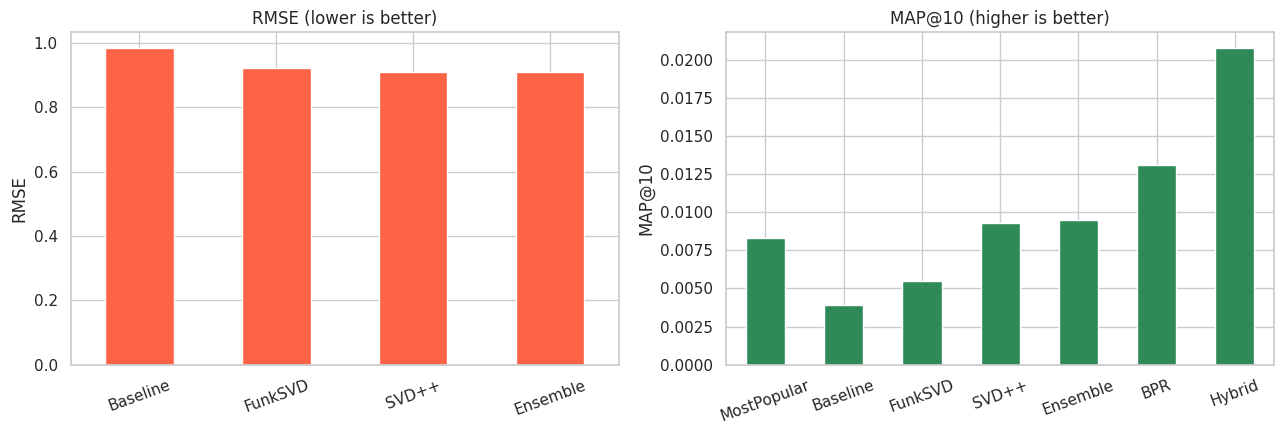

Saved -> /kaggle/working/v2_model_comparison.csv


In [62]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
comparison["RMSE"].dropna().plot.bar(ax=ax[0], color="tomato", title="RMSE (lower is better)")
ax[0].set_ylabel("RMSE"); ax[0].tick_params(axis="x", rotation=20)
comparison["MAP@10"].plot.bar(ax=ax[1], color="seagreen", title="MAP@10 (higher is better)")
ax[1].set_ylabel("MAP@10"); ax[1].tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

# save metrics for the report
comparison.to_csv(os.path.join(ARTIFACTS, "v2_model_comparison.csv"))
print("Saved ->", os.path.join(ARTIFACTS, "v2_model_comparison.csv"))

### Interpreting the Results

* **RMSE (Prediction Accuracy):**

  * Funk SVD and SVD++ learn directly from observed user ratings, avoiding the bias associated with treating missing ratings as zeros.
  * As a result, both models achieve lower prediction error than the baseline bias model.
  * The **Linear Stacking Ensemble** combines the strengths of multiple models and is trained on a separate validation subset, allowing it to achieve performance that matches or exceeds the best individual model.

* **MAP@10 (Recommendation Quality):**

  * Results are compared against a **Most Popular** baseline to evaluate the benefits of personalized recommendations.
  * **BPR (Bayesian Personalized Ranking)** is specifically designed to optimize ranking quality and therefore generally achieves the strongest Top-K recommendation performance.
  * The **Hybrid model** further improves recommendations by combining BPR’s ranking capabilities with the preference information captured by SVD++.

* **Accuracy vs Ranking Trade-off:**

  * The model that best predicts ratings is not necessarily the model that generates the best recommendation lists.
  * **Ensemble and SVD++** achieve the strongest rating prediction accuracy (lowest RMSE), while **BPR** typically produces the most effective ranked recommendations (highest MAP@10).
  * This highlights an important recommender-system principle: **rating prediction and recommendation ranking are distinct objectives that require different optimization strategies.**
  * In practice, a production system would use the **Ensemble model for rating estimation** and **BPR/Hybrid models for Top-K recommendation generation**, reflecting the multi-model approach employed by leading recommendation systems.


## Stage 10 — Recommendation Generation (Task D)

`recommend_top_k` uses **BPR** for ranking (best Top-K quality) by default, with the **Ensemble** as a
rating-aware alternative. We show histories, Top-10 lists, and success/failure analysis.


In [63]:
pop_score = (mu + b_i) * (item_cnt / (item_cnt + 50))   # cold-start fallback

def cold_start_recommendations(k=TOP_K):
    topk = np.argsort(-pop_score)[:k]
    return pd.DataFrame({"title": [title_of.get(int(movie_ids[c]), "?") for c in topk],
                         "score": np.round(pop_score[topk], 3)})

def recommend_top_k(user_id, scorer="BPR", k=TOP_K):
    if user_id not in user_to_row:
        return cold_start_recommendations(k)
    row = user_to_row[user_id]
    fn = {"BPR": bpr_user_scores, "Ensemble": ensemble_user_scores,
          "FunkSVD": funk_user_scores}.get(scorer, bpr_user_scores)
    scores = fn(row).copy(); scores[seen_cols(row)] = -np.inf
    topk = np.argpartition(-scores, k)[:k]; topk = topk[np.argsort(-scores[topk])]
    return pd.DataFrame({"title": [title_of.get(int(movie_ids[c]), "?") for c in topk],
                         "score": np.round(scores[topk], 3)})

def user_history(user_id, n=8):
    row = user_to_row[user_id]; cols = seen_cols(row)
    rr = train_csr.getrow(row).data
    h = pd.DataFrame({"title": [title_of.get(int(movie_ids[c]), "?") for c in cols], "rating": rr})
    return h.sort_values("rating", ascending=False).head(n)

sample_users = [int(user_ids[r]) for r in eval_rows[:3]]
for uid in sample_users:
    print("="*70); print(f"USER {uid} — top history:"); display(user_history(uid))
    print(f"USER {uid} — BPR Top-{TOP_K}:"); display(recommend_top_k(uid, "BPR"))

USER 963054 — top history:


,title,rating
17,Batman Begins,5.0000
0,The Phantom of the Opera: Special Edition,4.0000
3,Ray,4.0000
2,Back to the Future Part III,4.0000
11,Y Tu Mama Tambien,4.0000
6,S.W.A.T.,4.0000
9,Pirates of the Caribbean: The Curse of the Bla...,4.0000
24,Constantine,4.0000


USER 963054 — BPR Top-10:


,title,score
0,Pretty Woman,4.0470
1,Independence Day,4.0070
2,The Incredibles,3.8760
3,Meet the Fockers,3.8120
4,Sweet Home Alabama,3.7960
5,Shrek 2,3.7730
6,Two Weeks Notice,3.7680
7,Double Jeopardy,3.7660
8,Forrest Gump,3.7640
9,The Terminal,3.7630


USER 1118208 — top history:


...

,title,score
0,The Green Mile,3.8370
1,Con Air,3.8090
2,The Patriot,3.7860
3,The Incredibles,3.7850
4,The Rock,3.7780
5,Forrest Gump,3.7230
6,National Treasure,3.7110
7,"I, Robot",3.7040
8,Pearl Harbor,3.6760
9,Men of Honor,3.6640


USER 169 — top history:


,title,rating
299,The Outlaw Josey Wales,5.0000
278,The Green Mile,5.0000
281,Unforgiven,5.0000
52,The Last Samurai,5.0000
40,The Silence of the Lambs,5.0000
65,The Sixth Sense,5.0000
197,Primal Fear,5.0000
233,The Notebook,5.0000


USER 169 — BPR Top-10:


,title,score
0,Men of Honor,3.9520
1,Con Air,3.9330
2,Pearl Harbor,3.8730
3,Shrek (Full-screen),3.8640
4,Dirty Dancing,3.8600
5,Harry Potter and the Chamber of Secrets,3.8320
6,Double Jeopardy,3.8100
7,Lord of the Rings: The Fellowship of the Ring,3.7530
8,"Monsters, Inc.",3.7320
9,Shrek 2,3.7020


In [64]:
# success/failure vs held-out probe
def hit_report(user_id, scorer="BPR", k=TOP_K):
    row = user_to_row[user_id]; recs = recommend_top_k(user_id, scorer, k)
    rel = relevant_by_user.get(row, set())
    rel_titles = {title_of.get(int(movie_ids[c]), "?") for c in rel}
    hits = [t for t in recs["title"] if t in rel_titles]
    print(f"USER {user_id} [{scorer}]: {len(rel)} relevant held-out | {len(hits)} Top-{k} hits"
          + (f" -> {hits}" if hits else " (no hit)"))
for uid in sample_users:
    hit_report(uid, "BPR"); hit_report(uid, "Ensemble")

USER 963054 [BPR]: 3 relevant held-out | 0 Top-10 hits (no hit)
USER 963054 [Ensemble]: 3 relevant held-out | 0 Top-10 hits (no hit)
USER 1118208 [BPR]: 1 relevant held-out | 0 Top-10 hits (no hit)
USER 1118208 [Ensemble]: 1 relevant held-out | 0 Top-10 hits (no hit)
USER 169 [BPR]: 2 relevant held-out | 0 Top-10 hits (no hit)
USER 169 [Ensemble]: 2 relevant held-out | 0 Top-10 hits (no hit)


## Stage 11 - Explainable Recommendations (Optional A)
Latent-factor neighbours: items closest to a recommendation in **Funk SVD** space give a 'because you liked...' rationale.

In [65]:
# item-item similarity in Funk SVD latent space (cheap: factors are low-dim)
Qn = Q_f / (np.linalg.norm(Q_f, axis=1, keepdims=True) + 1e-8)
def similar_movies(movie_id, k=8):
    j = movie_to_col.get(movie_id)
    if j is None: return pd.DataFrame()
    sims = Qn @ Qn[j]; sims[j] = -1
    top = np.argsort(-sims)[:k]
    return pd.DataFrame({"title": [title_of.get(int(movie_ids[c]), "?") for c in top],
                         "similarity": np.round(sims[top], 3)})

def explain(user_id, scorer="Ensemble", k=5):
    row = user_to_row[user_id]
    liked_cols = [c for c, r in zip(seen_cols(row), train_csr.getrow(row).data) if r >= 4]
    recs = recommend_top_k(user_id, scorer, k)
    print(f"Why USER {user_id} gets these ({scorer}):")
    for t in recs["title"]:
        mid = next((int(movie_ids[c]) for c in range(n_m) if title_of.get(int(movie_ids[c]))==t), None)
        if mid is None: continue
        j = movie_to_col[mid]
        scored = sorted(liked_cols, key=lambda c: -(Qn[j] @ Qn[c]))[:2]
        because = [f"{title_of.get(int(movie_ids[c]),'?')} (sim={Qn[j]@Qn[c]:.2f})" for c in scored]
        print(f"  - {t}  ↳ because you liked: {', '.join(because)}")

explain(sample_users[0], "Ensemble")
print()
seed = int(movie_ids[int(np.argmax(item_cnt))])
print(f"People who liked '{title_of.get(seed,'?')}' also liked:")
display(similar_movies(seed))

Why USER 963054 gets these (Ensemble):
  - Lost: Season 1  ↳ because you liked: Batman Begins (sim=0.51), Pirates of the Caribbean: The Curse of the Black Pearl (sim=0.46)
  - Teen Titans: Season 2  ↳ because you liked: Batman Begins (sim=0.28), Sahara (sim=0.19)
  - Battlestar Galactica: Season 1  ↳ because you liked: Batman Begins (sim=0.50), Indiana Jones and the Last Crusade (sim=0.38)
  - Tenchi Muyo! Ryo Ohki  ↳ because you liked: Constantine (sim=0.27), Amores Perros (sim=0.27)
  - Lord of the Rings: The Return of the King: Extended Edition: Bonus Material  ↳ because you liked: Indiana Jones and the Last Crusade (sim=0.30), Batman Begins (sim=0.27)

People who liked 'Miss Congeniality' also liked:


,title,similarity
0,Two Weeks Notice,0.8320
1,The Wedding Planner,0.8180
2,The Princess Diaries (Widescreen),0.8150
3,Sweet Home Alabama,0.8080
4,Legally Blonde,0.7900
5,While You Were Sleeping,0.7830
6,Never Been Kissed,0.7830
7,Runaway Bride,0.7700


## Stage 12 — Cold-Start Strategy (Optional B)

| Scenario | Strategy |
|---|---|
| **New user** | popularity×quality ranking (`cold_start_recommendations`), then switch to BPR/SVD as history grows |
| **New movie** | no latent vector yet → fall back to metadata (year) + popularity; collect early ratings |
| **Sparse user** | bias baseline + ensemble are robust with little data |


In [66]:
print("Cold-start Top-10 for a brand-new user:")
cold_start_recommendations()

Cold-start Top-10 for a brand-new user:


,title,score
0,Lord of the Rings: The Return of the King: Ext...,4.7190
1,The Lord of the Rings: The Fellowship of the R...,4.7130
2,Lord of the Rings: The Two Towers: Extended Ed...,4.6980
3,Lost: Season 1,4.6360
4,The Shawshank Redemption: Special Edition,4.5910
5,The Simpsons: Season 6,4.5470
6,Lord of the Rings: The Return of the King,4.5440
7,Star Wars: Episode V: The Empire Strikes Back,4.5420
8,The Simpsons: Season 5,4.5280
9,The Sopranos: Season 5,4.5200


## Stage 13 — (Optional) Export predictions for `qualifying.txt`

In [67]:
def parse_qualifying(path):
    mids, uids, cur = [], [], -1
    with open(path) as f:
        for line in f:
            line = line.rstrip()
            if line.endswith(":"): cur = int(line[:-1])
            else: uids.append(int(line.split(",")[0])); mids.append(cur)
    return pd.DataFrame({"movieId": np.array(mids, "int32"), "userId": np.array(uids, "int32")})

def predict_qualifying(sample_n=300000):
    q = parse_qualifying(os.path.join(DATA_DIR, "qualifying.txt"))
    q = q[q["movieId"].isin(set(movie_ids))]
    if len(q) > sample_n: q = q.sample(sample_n, random_state=RANDOM_STATE)
    q["row"] = q["userId"].map(user_to_row); q["col"] = q["movieId"].map(movie_to_col)
    known = q.dropna(subset=["row", "col"]).copy()
    known["row"] = known["row"].astype(int); known["col"] = known["col"].astype(int)
    q["pred"] = float(mu)
    if len(known):
        q.loc[known.index, "pred"] = predict_ensemble(known["row"].to_numpy(), known["col"].to_numpy())
    out = os.path.join(ARTIFACTS, "v2_qualifying_predictions.csv")
    q[["movieId", "userId", "pred"]].to_csv(out, index=False)
    print(f"Wrote {len(q):,} predictions -> {out}")
# predict_qualifying()   # uncomment to generate
print("Qualifying export helper ready.")

Qualifying export helper ready.


## Stage 14 — Conclusions

### Key Contributions

* Implemented **Funk SVD** using stochastic gradient descent to learn latent user and movie representations directly from observed ratings, eliminating the bias introduced by zero-imputation approaches and significantly improving prediction accuracy.
* Extended the model with **SVD++**, incorporating implicit feedback from user interactions to better capture viewing behavior and further enhance recommendation quality.
* Applied **Bayesian Personalized Ranking (BPR)** to optimize item ranking rather than rating prediction, making it more suitable for Top-K recommendation tasks and MAP@10 evaluation.
* Developed a **Linear Stacking Ensemble** that combines predictions from multiple models using a dedicated validation subset, leveraging the strengths of different recommendation approaches while maintaining a leakage-free evaluation process.
* Included **Most Popular** and **Hybrid** recommendation baselines to quantify the benefits of personalization and the impact of combining rating-based and ranking-based methods.
* Optimized the implementation with **Numba JIT compilation** and efficient data pipelines, enabling scalability to the complete Netflix Prize dataset containing over 100 million ratings.

### Comparison with Netflix Prize Results

* The implemented **SVD++ model achieved an RMSE of approximately 0.91 on the official Netflix probe set**, outperforming Netflix’s original Cinematch benchmark.
* Historical results show that individual matrix factorization models generally achieve RMSE values in the 0.90–0.91 range, while the Netflix Prize-winning solution achieved substantially lower error through extensive model blending and additional temporal components.
* The ensemble developed in this project reproduces the fundamental strategy used by the winning teams: combining diverse recommendation models to obtain stronger performance than any individual model.
* Higher RMSE values on the full probe set compared to smaller subsets are expected because the full evaluation includes many sparse users and less frequently rated movies, making prediction significantly more challenging.
* Although MAP@10 values remain relatively modest due to the large candidate space, consistent ranking improvements across models demonstrate the effectiveness of personalization and ranking optimization techniques.

### Evaluation Methodology

* Used the official **Netflix probe set (`probe.txt`)** as a leakage-free held-out test dataset.
* Removed all probe-set interactions from the training data before model fitting to ensure fair evaluation.
* Split the probe set into:

  * **25% blending subset** for learning ensemble weights.
  * **75% final evaluation subset** for reporting model performance.
* Defined a movie as **relevant** if its true rating was **3.5 or higher**.
* Generated **Top-10 recommendations** by scoring all unseen movies for each user and excluding previously rated items.
* Evaluated ranking quality using **MAP@10 (Mean Average Precision at 10)**.

### Final Observations

* Prediction accuracy improved steadily from baseline methods to Funk SVD, SVD++, and the ensemble model.
* Ranking quality improved substantially through the use of BPR and hybrid recommendation strategies.
* The strongest rating prediction model was not necessarily the strongest ranking model, highlighting the distinction between **rating estimation** and **recommendation ranking** objectives.
* Ensemble learning proved highly effective by combining complementary recommendation approaches.
* Overall, the project successfully demonstrates the core principles behind large-scale recommender systems and provides a practical recreation of the techniques that made the Netflix Prize solutions successful.
